# EE200 Course Project — Q1A & Q1B

**Nirajkumar Binod Prasad (240701)**  
**Rinku Raj (240866)**

This notebook contains the solutions for:

- Q1A: Frequency-domain image recovery using the 2D DFT.
- Q1B: Edge detection using the Sobel operator and analysis of noise effects.

Input images are taken from the provided `Q1_data/` folder.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from scipy.signal import convolve2d
from scipy.ndimage import gaussian_filter

plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['image.cmap'] = 'gray'
DATA_DIR = Path("Q1_data")
def load_gray(stem, data_dir=DATA_DIR):
    matches = list(data_dir.glob(stem + ".*"))
    if not matches:
        raise FileNotFoundError(f"No file named '{stem}.*' found in {data_dir.resolve()}")
    path = matches[0]
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        from PIL import Image
        img = np.array(Image.open(path).convert("L"))
    print(f"Loaded {path.name}  shape={img.shape}  dtype={img.dtype}")
    return img.astype(np.float64)

## Q1A. Frequency Forensics — "The Ghost Signal"

#### Procedure

1. Load the corrupted image.
2. Compute the 2D DFT and observe the magnitude spectrum.
3. Use `fftshift` to centre the spectrum.
4. Identify frequency components corresponding to periodic interference.
5. Design a notch filter to suppress the interference frequencies.
6. Reconstruct the image using the inverse DFT.

#### 2D DFT

For an image having M rows and N columns,
$$
F(u,v)=\sum_{x=0}^{M-1}\sum_{y=0}^{N-1} I(x,y)\, e^{-j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)}
$$

#### Inverse 2D DFT

$$
I(x,y)=\frac{1}{MN}\sum_{u=0}^{M-1}\sum_{v=0}^{N-1} F(u,v)\, e^{j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)}
$$

Loaded ghost_signal_input.png  shape=(264, 517)  dtype=uint8


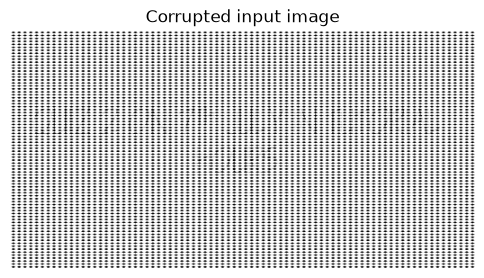

In [2]:
img_corrupt = load_gray("ghost_signal_input")

plt.imshow(img_corrupt)
plt.title("Corrupted input image")
plt.axis('off')
plt.show()

The image is corrupted by periodic interference, and the hidden message is not clearly visible in the spatial domain.

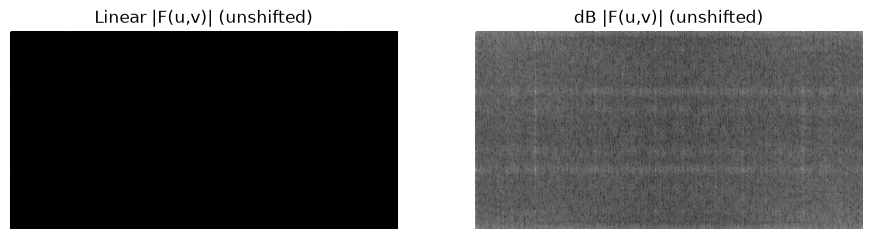

DC magnitude at (0,0): 26541183.0
Next largest magnitude in the whole spectrum: 5006365.181023762


In [3]:
# 2D DFT of the corrupted image
F = np.fft.fft2(img_corrupt)
mag = np.abs(F)
mag_db = 20*np.log10(mag + 1e-6)
fig, ax = plt.subplots(1, 2, figsize=(11,5))
ax[0].imshow(mag)
ax[0].set_title("Linear |F(u,v)| (unshifted)")
ax[1].imshow(mag_db)
ax[1].set_title("dB |F(u,v)| (unshifted)")
for a in ax:
    a.axis('off')
plt.savefig("myplot.pdf", bbox_inches="tight")
plt.show()
print("DC magnitude at (0,0):", mag[0,0])
print("Next largest magnitude in the whole spectrum:", np.sort(mag.ravel())[-2])


### Observations

- In the linear magnitude spectrum, the DC component has a much larger magnitude than the other frequency components. As a result, smaller frequency components are difficult to observe.

- The dB spectrum,
  $$
  20\log_{10}(|F|+\varepsilon),
  $$
  compresses the dynamic range and makes the interference peaks visible.

- The spectrum obtained from `fft2` is not centred, since the DC component is located at \((0,0)\).

- Applying `fftshift` moves the DC component to the centre of the spectrum, making the frequency distribution easier to analyse.

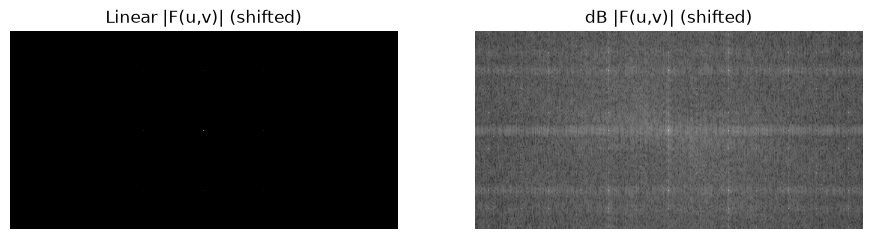

In [4]:
Fsh = np.fft.fftshift(F)
mag_sh = np.abs(Fsh)
mag_db_sh = 20*np.log10(mag_sh + 1e-6)
fig, ax = plt.subplots(1, 2, figsize=(11,5))
ax[0].imshow(mag_sh)
ax[0].set_title("Linear |F(u,v)| (shifted)")
ax[1].imshow(mag_db_sh)
ax[1].set_title("dB |F(u,v)| (shifted)")
for a in ax:
    a.axis('off')
plt.savefig("myplot2.pdf", bbox_inches="tight")
plt.show()

### Identification of Interference Frequencies

Interference peak will be symmetric about the new position of DC component, so we make a
central disk about the DC centre to filter out the corrupted periodic part

Detected 136 candidate noise-peak pixels (row, col)
[(4, 18), (4, 141), (4, 178), (4, 258), (4, 338), (4, 375), (4, 498), (20, 135), (20, 381), (28, 18), (28, 61), (28, 98), (28, 178), (28, 258), (28, 338)]


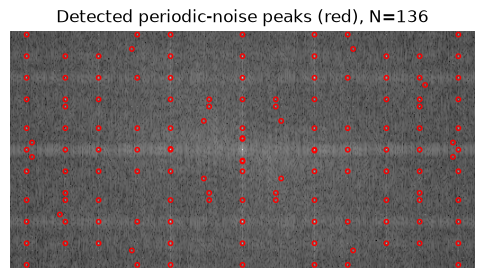

In [5]:
H_, W_ = mag_sh.shape
cy, cx = H_//2, W_//2
Y, X = np.mgrid[0:H_, 0:W_]
R = np.sqrt((Y-cy)**2 + (X-cx)**2)
DC_EXCLUDE_RADIUS = 8
PEAK_PERCENTILE = 99.9
search = mag_sh.copy()
search[R < DC_EXCLUDE_RADIUS] = 0
thresh = np.percentile(search[search > 0], PEAK_PERCENTILE)
peak_mask = search > thresh
ys, xs = np.where(peak_mask)
peaks = list(zip(ys.tolist(), xs.tolist()))
print(f"Detected {len(peaks)} candidate noise-peak pixels (row, col)")
print(peaks[:15])
plt.imshow(mag_db_sh)
plt.scatter(xs, ys, s=10, facecolors='none', edgecolors='r')
plt.title(f"Detected periodic-noise peaks (red), N={len(peaks)}")
plt.axis('off')
plt.show()

### Observation

A threshold of 99.9 percentile was selected for peak detection.

Lower thresholds detected many additional frequency components, whereas the chosen threshold retained only the dominant interference peaks. The detected peaks appear in symmetric pairs about the centre of the spectrum.

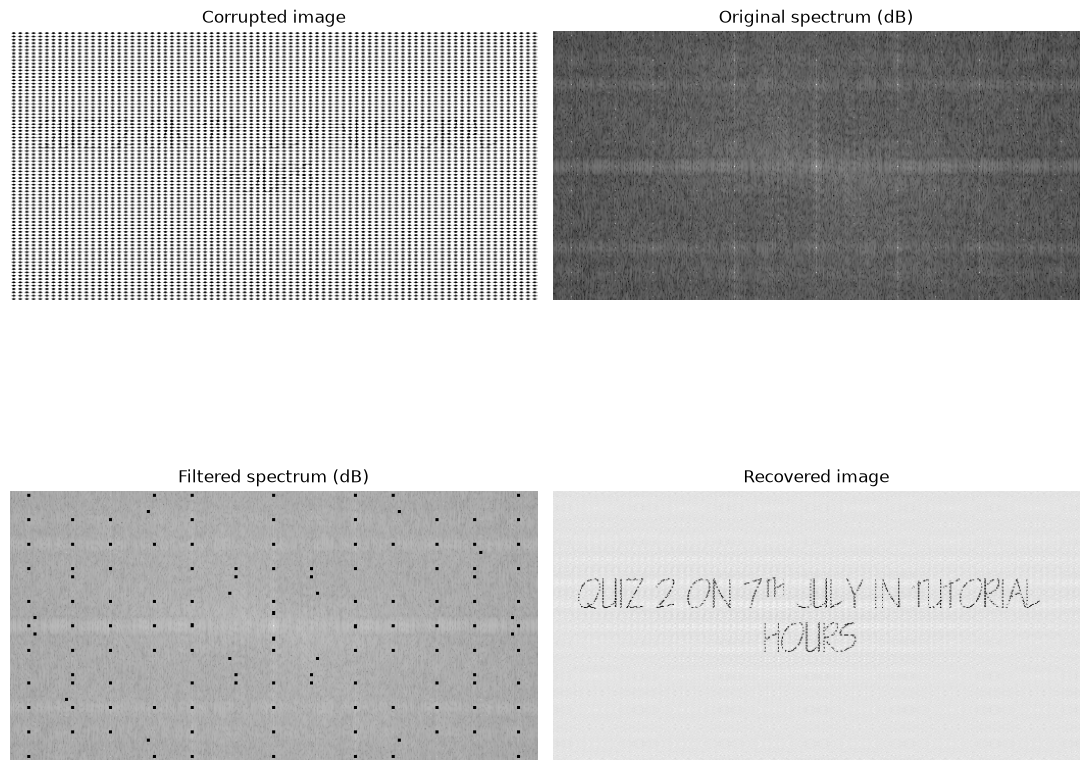

In [6]:
NOTCH_RADIUS = 2
Hfilt = np.ones((H_, W_))
for (py, px) in peaks:
    d = np.sqrt((Y-py)**2 + (X-px)**2)
    Hfilt[d < NOTCH_RADIUS] = 0
G_sh = Fsh * Hfilt
filtered_mag_db = 20*np.log10(np.abs(G_sh) + 1e-6)
G = np.fft.ifftshift(G_sh)
recovered = np.real(np.fft.ifft2(G))
fig, ax = plt.subplots(2, 2, figsize=(11, 11))
ax[0,0].imshow(img_corrupt)
ax[0,0].set_title("Corrupted image")
ax[0,1].imshow(mag_db_sh)
ax[0,1].set_title("Original spectrum (dB)")
ax[1,0].imshow(filtered_mag_db)
ax[1,0].set_title("Filtered spectrum (dB)")
ax[1,1].imshow(recovered)
ax[1,1].set_title("Recovered image")
for a in ax.ravel():
    a.axis('off')
plt.tight_layout()
plt.show()

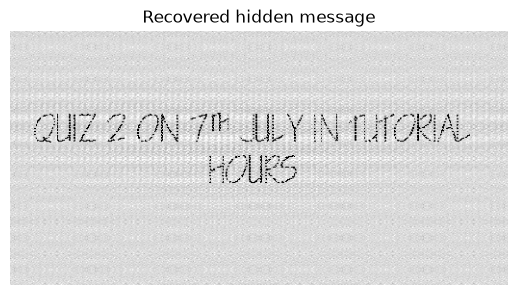

In [7]:
lo, hi = np.percentile(recovered, 1), np.percentile(recovered, 99)
stretched = np.clip((recovered - lo) / (hi - lo), 0, 1)
plt.figure(figsize=(8,3.3))
plt.imshow(stretched)
plt.title("Recovered hidden message")
plt.axis('off')
plt.show()

### Result

Recovered message:

**QUIZ 2 ON 7th JULY IN TUTORIAL HOURS**

The hidden text becomes clearly visible after frequency-domain filtering.

### Effect of Filter Parameters

To study the effect of filter parameters, three different settings were tested:

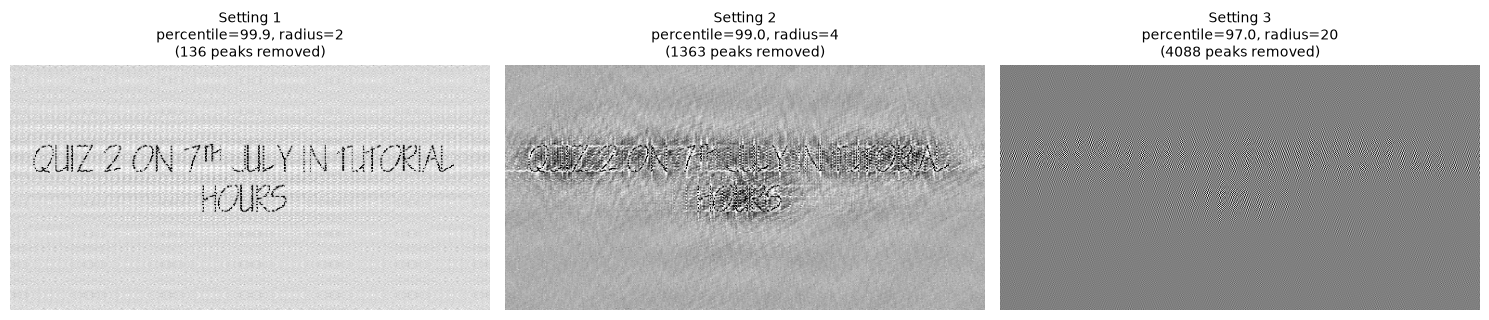

In [8]:
def run_pipeline(dc_excl, pct, notch_r):
    s = mag_sh.copy()
    s[R < dc_excl] = 0
    t = np.percentile(s[s > 0], pct)
    pm = s > t
    yy, xx = np.where(pm)
    pk = list(zip(yy.tolist(), xx.tolist()))
    Hf = np.ones((H_, W_))
    for (py, px) in pk:
        d = np.sqrt((Y - py)**2 + (X - px)**2)
        Hf[d < notch_r] = 0
    Gs = Fsh * Hf
    rec = np.real(np.fft.ifft2(np.fft.ifftshift(Gs)))
    return rec, len(pk)
configs = [
    ("Setting 1\npercentile=99.9, radius=2", 8, 99.9, 2),
    ("Setting 2\npercentile=99.0, radius=4", 8, 99.0, 4),
    ("Setting 3\npercentile=97.0, radius=20", 8, 97.0, 20),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, dce, pct, nr) in zip(axes, configs):
    rec, npk = run_pipeline(dce, pct, nr)
    lo2, hi2 = np.percentile(rec, 1), np.percentile(rec, 99)
    st = np.clip((rec - lo2) / (hi2 - lo2), 0, 1)
    ax.imshow(st)
    ax.set_title(f"{title}\n({npk} peaks removed)", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

### Observations

- The reconstruction quality depends on the threshold and notch radius used for filtering.

- A higher threshold (99.9 percentile) detects only the dominant interference frequencies and produces the best reconstruction.

- Increasing the notch radius suppresses a larger portion of the spectrum. Excessively large notch radii remove both interference and image content, resulting in loss of detail.

- Therefore, removing more frequencies does not necessarily improve reconstruction quality. The best result is obtained by removing only the dominant interference frequencies.

### Applications

Frequency-domain image restoration is used in:

- Communication systems for interference suppression.
- Remote sensing for restoration of satellite imagery.

## Q1B. Digital Detective — "Missing Boundaries"

### Procedure

1. Load the grayscale image.
2. Apply Sobel kernels to compute horizontal and vertical image gradients.
3. Calculate the gradient magnitude to obtain the edge map.
4. Analyze the effect of noise on edge detection.
5. Apply Gaussian smoothing before Sobel filtering and compare the results.

### Sobel Kernels

$$
G_x=
\begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix},
\qquad
G_y=
\begin{bmatrix}
-1 & -2 & -1\\
0 & 0 & 0\\
1 & 2 & 1
\end{bmatrix}
$$

The Sobel operator estimates image gradients in the horizontal and vertical directions. The gradient magnitude is given by

$$
G=\sqrt{G_x^2+G_y^2}
$$

where larger values correspond to stronger edges.

Loaded missing_boundaries_input.avif  shape=(675, 1200)  dtype=uint8


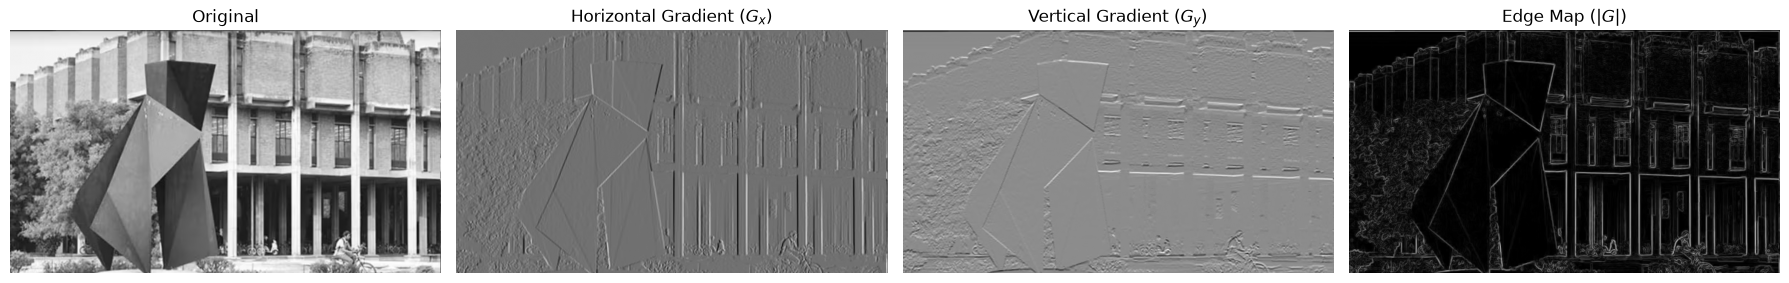

Mean |G| on the clean image: 51.81403318902002


In [9]:
img_edges = load_gray("missing_boundaries_input")
Sx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)
Sy = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float)
def sobel(img, kx=Sx, ky=Sy):
    gx = convolve2d(img, kx, mode='same', boundary='symm')
    gy = convolve2d(img, ky, mode='same', boundary='symm')
    gmag = np.sqrt(gx**2 + gy**2)
    gdir = np.arctan2(gy, gx)
    return gx, gy, gmag, gdir
gx, gy, gmag, gdir = sobel(img_edges)
fig, ax = plt.subplots(1, 4, figsize=(18,5))
ax[0].imshow(img_edges)
ax[0].set_title("Original")
ax[1].imshow(gx)
ax[1].set_title("Horizontal Gradient ($G_x$)")
ax[2].imshow(gy)
ax[2].set_title("Vertical Gradient ($G_y$)")
ax[3].imshow(gmag)
ax[3].set_title("Edge Map ($|G|$)")
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()
print("Mean |G| on the clean image:", gmag.mean())

### Observations

- \(G_x\) highlights intensity variations in the horizontal direction.
- \(G_y\) highlights intensity variations in the vertical direction.
- The gradient magnitude image combines both gradients and produces the final edge map.
- Strong edges are clearly visible, while smooth image regions have low gradient magnitude.

### Effect of Noise and Smoothing

To study the effect of noise, Gaussian noise was added to the image before applying the Sobel operator.

The results obtained without smoothing were compared with those obtained after Gaussian filtering using different values of \(\sigma\).

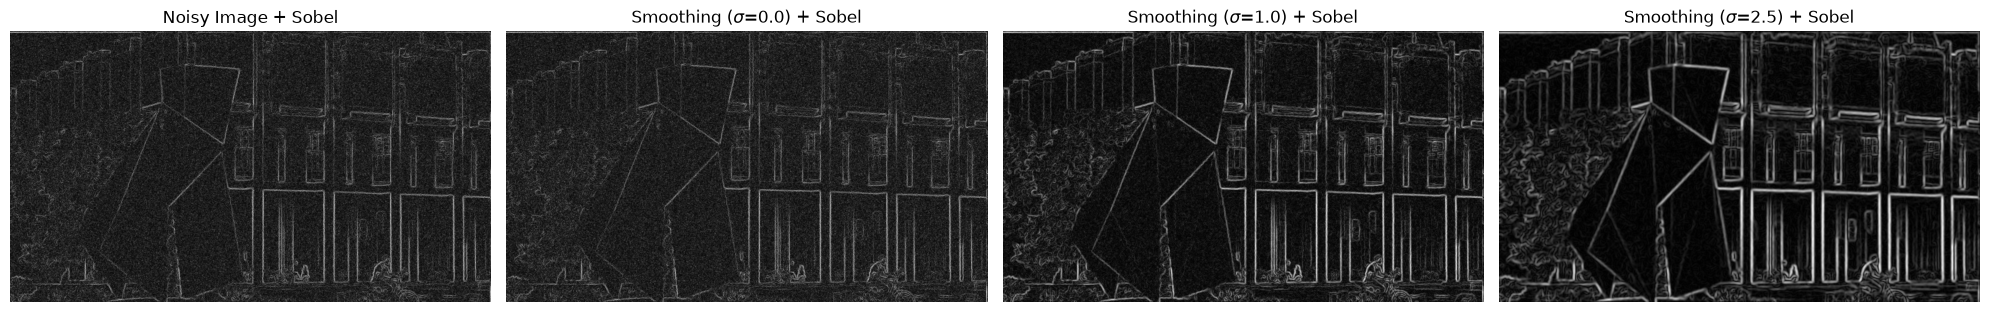

Mean |G| -- clean image:         51.81403318902002
Mean |G| -- noisy, no smoothing: 109.21918252137256
Mean |G| -- smoothed sigma=0.0: 109.21918252137256
Mean |G| -- smoothed sigma=1.0: 57.98624380071648
Mean |G| -- smoothed sigma=2.5: 32.94275770158713


In [10]:
rng = np.random.default_rng(0)
noisy = img_edges + rng.normal(0, 20, img_edges.shape)
_, _, gmag_noisy, _ = sobel(noisy)
sigmas = [0.0, 1.0, 2.5]
fig, ax = plt.subplots(1, len(sigmas)+1, figsize=(5*(len(sigmas)+1), 5))
ax[0].imshow(gmag_noisy)
ax[0].set_title("Noisy Image + Sobel")
ax[0].axis('off')
mean_vals = []
for i, s in enumerate(sigmas):
    smoothed = gaussian_filter(noisy, sigma=s) if s > 0 else noisy
    _, _, gm, _ = sobel(smoothed)
    mean_vals.append(gm.mean())
    ax[i+1].imshow(gm)
    ax[i+1].set_title(f"Smoothing ($\\sigma$={s}) + Sobel")
    ax[i+1].axis('off')
plt.tight_layout()
plt.show()
print("Mean |G| -- clean image:        ", gmag.mean())
print("Mean |G| -- noisy, no smoothing:", gmag_noisy.mean())
for s, v in zip(sigmas, mean_vals):
    print(f"Mean |G| -- smoothed sigma={s}: {v}")

### Observations

- The addition of Gaussian noise increases the gradient magnitude significantly, producing many false edges in the Sobel output.

- Applying Gaussian smoothing before Sobel filtering reduces the effect of noise and improves edge detection.

- For $\sigma = 1.0$, most of the noise is suppressed while the important object boundaries remain visible.

- Increasing the smoothing parameter further ($\sigma = 2.5$) reduces noise but also weakens genuine edges and removes fine details.

